In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from PIL import Image

#### β = (aᵀb) / (aᵀa)

You're at point b (4, 1)
You want to walk straight to the line a (direction 2, 5)
But you must walk PERPENDICULAR to the line

β tells you: "Walk β steps in direction a"
β = 0.52 means you go 0.52 × (2, 5) = (1.04, 2.59)
That's your closest point on the line!

<table>
<tr>
<td><b>Concept</b></td>
<td><b>Symbol</b></td>
<td><b>What it is</b></td>
<td><b>Example</b></td>
</tr>
<tr>
<td>β (beta)</td>
<td>β</td>
<td>Number of steps along vector a</td>
<td>β = 0.52 means take half a step</td>
</tr>
<tr>
<td>Angle</td>
<td>θ</td>
<td>Rotation between vectors</td>
<td>θ = 60° means vectors are 60° apart</td>
</tr>
<tr>
<td>Projection</td>
<td>β·a</td>
<td>Final position on the line</td>
<td>(1.04, 2.59)</td>
</tr>
</table>

بتا مقداری هست که روی خط (آ) باید برم تا بتونم از نقطه (ب) به صورت عمود و قائم به خط آ برسم

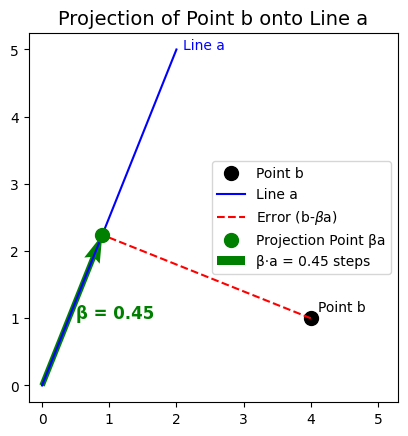

Line direction: a = [2 5]
Point to project: b = [4 1]
β = (aᵀb) / (aᵀa) = 13 / 29 = 0.448
This means: take 0.448 steps in direction a
Projection point: βa = 0.448 * [2 5] = [0.89655172 2.24137931]
Error (residual): b - βa = [ 3.10344828 -1.24137931]
Is error perpendicular to line? 0.0000000000 ≈ 0 ✓
β·a = 0.448 × (2, 5) = (0.90, 2.24)


In [3]:
a = np.array([2, 5]) # line
b = np.array([4, 1]) # point

beta = (a.T@b) / (a.T@a)
projection = beta*a

# plot
plt.plot(b[0], b[1], 'ko', markersize=10, label='Point b') # point b
plt.plot([0, a[0]], [0, a[1]], 'b', label='Line a') # line a
plt.plot([b[0], projection[0]], [b[1], projection[1]], 'r--', label=r'Error (b-$\beta$a)')
plt.plot(projection[0], projection[1], 'go', markersize=10, label='Projection Point βa')
plt.quiver(0, 0, beta*a[0], beta*a[1], angles='xy', scale_units='xy', scale=1, 
           color='green', width=0.015, label=f'β·a = {beta:.2f} steps')
plt.annotate(f'β = {beta:.2f}', (beta*a/2), fontsize=12, color='green', fontweight='bold', xytext=(0.5, 1))
plt.text(x=b[0]+.1, y=b[1]+.1, s='Point b')
plt.text(x=a[0]+.1, y=a[1], s='Line a', color='b')
plt.axis('square')
plt.legend()
plt.title('Projection of Point b onto Line a', fontsize=14)
plt.show()

print(f"Line direction: a = {a}")
print(f"Point to project: b = {b}")
print(f"β = (aᵀb) / (aᵀa) = {np.dot(a, b)} / {np.dot(a, a)} = {beta:.3f}")
print(f"This means: take {beta:.3f} steps in direction a")
print(f"Projection point: βa = {beta:.3f} * {a} = {projection}")
print(f"Error (residual): b - βa = {b - projection}")
print(f"Is error perpendicular to line? {np.dot(a, b - projection):.10f} ≈ 0 ✓")
print(f"β·a = {beta:.3f} × ({a[0]}, {a[1]}) = ({beta*a[0]:.2f}, {beta*a[1]:.2f})")

#### ML Connection: Linerar Regression

In [ ]:
img = Image.open('../img/projection_rn.png')
aspect = 1
img.resize((int(img.size[0] * aspect), int(img.size[1] * aspect)))

β in linear regression = projection coefficient

This is the normal equation: $\beta = (X^T X)^{-1} X^T y$

In [ ]:
# Features (the "line" / subspace)
X = np.array([[1, 2], 
              [1, 3], 
              [1, 4]])  # First column is bias term

# Target (the point to project)
y = np.array([2, 3, 4])

'''
Linear Algebra Projection:
'''
# β in linear regression = projection coefficient
# β = (X^T X)^(-1) X^T y  (same formula!)
beta = np.linalg.inv(X.T @ X) @ X.T @ y

print(f"β coefficients: {beta}")
print(f"β[0] = intercept: {beta[0]:.2f}")
print(f"β[1] = slope: {beta[1]:.2f}")

# Prediction = projection onto feature space
y_pred = X @ beta
print(f"Predictions: {y_pred}")

'''
Logistic Regression:
'''
print("="*50)
X_ = X[:, 1].reshape(-1, 1) # without the bias term since LinearRegression adds it automatically
model = LinearRegression()  # fit_intercept=True by default
model.fit(X_, y)

print(f"Intercept (β0): {model.intercept_:.2f}")
print(f"Slope (β1): {model.coef_[0]:.2f}")

# Prediction = projection onto feature space
y_pred = model.predict(X_)
print(f"Predictions: {y_pred}")

<table>
  <thead>
    <tr>
      <th align="left">ML Concept</th>
      <th align="left">What β Represents</th>
      <th align="left">Why It's Projection</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td align="left">Linear Regression</td>
      <td align="left">Model weights</td>
      <td align="left">Predictions = projection onto feature space</td>
    </tr>
    <tr>
      <td align="left">PCA</td>
      <td align="left">Principal components</td>
      <td align="left">Data projected onto max variance directions</td>
    </tr>
    <tr>
      <td align="left">Neural Networks</td>
      <td align="left">Layer weights</td>
      <td align="left">Each layer projects input to new space</td>
    </tr>
    <tr>
      <td align="left">SVM</td>
      <td align="left">Hyperplane normal</td>
      <td align="left">Decision boundary = projection onto hyperplane</td>
    </tr>
    <tr>
      <td align="left">Recommendation</td>
      <td align="left">User preferences</td>
      <td align="left">Items projected onto user's taste space</td>
    </tr>
    <tr>
      <td align="left">Feature Selection</td>
      <td align="left">Feature importance</td>
      <td align="left">β magnitude = projection importance</td>
    </tr>
  </tbody>
</table>

<!-- In a Jupyter markdown cell, paste this: -->

Every ML model is essentially finding the best projection (β) that:

- Minimizes error (regression)
- Maximizes separation (classification)
- Captures variance (dimensionality reduction)
- Represents relationships (embedding)

#### Gram-Schmidt

takes messy data and makes it "nice" by removing redundancies and creating independent features. It's the mathematical equivalent of organizing a messy closet!

In [ ]:
# Original vectors (not orthogonal)
v1 = np.array([2, 1])
v2 = np.array([1, 3])

# Step 1: First vector stays the same (just normalize)
u1 = v1 / np.linalg.norm(v1)

# Step 2: Project v2 onto u1 and subtract
proj_v2_onto_u1 = np.dot(v2, u1) * u1
u2_raw = v2 - proj_v2_onto_u1
u2 = u2_raw / np.linalg.norm(u2_raw)

# Verification
dot_product_v = np.dot(v1, v2)
dot_product_u = np.dot(u1, u2)
print(f"Dot product v (not orthogonal): {dot_product_v:.10f}")
print(f"Dot product u (orthogonal): {dot_product_u:.10f}")
print(f"Is orthogonal? {np.isclose(dot_product_u, 0)}")

angle_rad = np.arccos(np.dot(u1, u2) / (np.linalg.norm(u1) * np.linalg.norm(u2)))
angle_deg = np.degrees(angle_rad)
print(f"Angle: {angle_deg:.2f} degrees")

In [ ]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before
ax = axes[0]
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, 
          color='blue', width=0.015, label='v1')
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, 
          color='red', width=0.015, label='v2')
ax.set_xlim(-0.5, 3)
ax.set_ylim(-0.5, 4)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('Before: v1 and v2 (not orthogonal)')
ax.legend()

# After
ax = axes[1]
ax.quiver(0, 0, u1[0], u1[1], angles='xy', scale_units='xy', scale=1, 
          color='blue', width=0.015, label='u1 (normalized v1)')
ax.quiver(0, 0, u2[0], u2[1], angles='xy', scale_units='xy', scale=1, 
          color='green', width=0.015, label='u2 (perp to u1)')
ax.set_xlim(-0.5, 3)
ax.set_ylim(-0.5, 4)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title(r'After: $u_1 \perp u_2$ (orthogonal)')
ax.legend()

plt.tight_layout()
plt.show()

#### QR Decomposition

<!-- In a Jupyter markdown cell, paste this: -->

**QR decomposition** is a way of factoring a matrix **A** into two matrices:

- **Q** = Orthogonal matrix (columns are orthonormal)
- **R** = Upper triangular matrix

Where: **A = QR**

Think of it as: Taking a messy matrix and separating it into "the nice perpendicular directions" (Q) and "how much to move in each direction" (R) - like giving directions: "Go north 3 blocks (Q), then east 5 blocks (R)"!

## QR vs Other Decompositions

| Decomposition | What it does | Best for |
|:--------------|:-------------|:---------|
| **QR** | A = Q × R (orthogonal × triangular) | Least squares, stable regression |
| **LU** | A = L × U (lower × upper triangular) | Solving linear systems |
| **SVD** | A = U × Σ × V<sup>T</sup> | PCA, dimensionality reduction |
| **Eigen** | A = V × Λ × V<sup>-1</sup> | Eigendecomposition |

In [ ]:
A = np.array([[1, 0],
              [1, 0],
              [0, 1]])
Q, R = np.linalg.qr(A, 'complete')
print(Q)
Q, R = np.linalg.qr(A, 'reduced')
print(Q)

In [ ]:
# Original Matrix
A = np.array([[1, 0],
              [1, 1]])
# QR decomposition with complete mode
Q, R = np.linalg.qr(A, 'complete')

# ============================================
# VISUALIZATION 1: Original columns of A
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('QR Decomposition Visualization: A = [[1, 0], [1, 1]]', fontsize=16)

# Plot 1: Original columns of A
ax1 = axes[0, 0]
origin = np.array([0, 0])

# Column 1 of A: [1, 1]
col1 = A[:, 0]
# Column 2 of A: [0, 1]
col2 = A[:, 1]

ax1.quiver(*origin, *col1, angles='xy', scale_units='xy', scale=1, color='red', width=0.02, label=f'a₁ = [{col1[0]}, {col1[1]}]')
ax1.quiver(*origin, *col2, angles='xy', scale_units='xy', scale=1, color='blue', width=0.02, label=f'a₂ = [{col2[0]}, {col2[1]}]')

# Draw the parallelogram
ax1.plot([col1[0], col1[0]+col2[0]], [col1[1], col1[1]+col2[1]], 'k--', alpha=0.3) # (x1, x1+x2) (x2, x1+x2)
ax1.plot([col2[0], col1[0]+col2[0]], [col2[1], col2[1]+col1[1]], 'k--', alpha=0.3) # (y1, y1+y2) (y2, y1+y2)

ax1.set_xlim([-0.5, 2])
ax1.set_ylim([-0.5, 2])
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')
ax1.set_title('Original Columns of A\n(Not orthogonal, not unit length)')
ax1.legend()
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.2)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.2)

# ============================================
# VISUALIZATION 2: Q columns (orthonormal basis)
# ============================================
ax2 = axes[0, 1]

# Q columns
q1 = Q[:, 0]  # First orthonormal vector
q2 = Q[:, 1]  # Second orthonormal vector

ax2.quiver(*origin, *q1, angles='xy', scale_units='xy', scale=1, color='red', width=0.025, label=f'q₁ = [{q1[0]:.3f}, {q1[1]:.3f}]')
ax2.quiver(*origin, *q2, angles='xy', scale_units='xy', scale=1, color='blue', width=0.025, label=f'q₂ = [{q2[0]:.3f}, {q2[1]:.3f}]')

# Draw unit circle
theta = np.linspace(0, 2*np.pi, 100)
ax2.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.2, label='Unit circle')

ax2.set_xlim([-1.5, 1.5])
ax2.set_ylim([-1.5, 1.5])
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')
ax2.set_title('Q Columns (Orthonormal Basis)\nPerpendicular, unit length')
ax2.legend()
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.2)
ax2.axvline(x=0, color='k', linestyle='-', alpha=0.2)

# ============================================
# VISUALIZATION 4: R matrix heatmap
# ============================================
ax4 = axes[1, 0]
im = ax4.imshow(R, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax4.set_xticks(range(R.shape[1]))
ax4.set_yticks(range(R.shape[0]))
ax4.set_xticklabels(['col 1', 'col 2'])
ax4.set_yticklabels(['row 1', 'row 2'])
ax4.set_title('R Matrix (Upper Triangular)')

# Add text annotations
for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        text = ax4.text(j, i, f'{R[i, j]:.2f}',
                       ha="center", va="center", 
                       color="white" if abs(R[i,j]) > 1 else "black",
                       fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax4)


In [ ]:
# ============================================
# PRINT DETAILED ANALYSIS
# ============================================
print("\n" + "="*60)
print("DETAILED ANALYSIS")
print("="*60)

print("\n1. Original columns of A:")
print(f"   a₁ = [{col1[0]}, {col1[1]}]")
print(f"   a₂ = [{col2[0]}, {col2[1]}]")
print(f"   a₁ · a₂ = {np.dot(col1, col2)} (Not orthogonal!)")
print(f"   ||a₁|| = {np.linalg.norm(col1):.3f}, ||a₂|| = {np.linalg.norm(col2):.3f}")

print("\n2. After QR decomposition (Q columns):")
print(f"   q₁ = [{q1[0]:.3f}, {q1[1]:.3f}]")
print(f"   q₂ = [{q2[0]:.3f}, {q2[1]:.3f}]")
print(f"   q₁ · q₂ = {np.dot(q1, q2):.3f} (Orthogonal!)")
print(f"   ||q₁|| = {np.linalg.norm(q1):.3f}, ||q₂|| = {np.linalg.norm(q2):.3f}")

print("\n3. R matrix (upper triangular):")
print(f"   R = [[{R[0,0]:.3f}, {R[0,1]:.3f}],")
print(f"        [{R[1,0]:.3f}, {R[1,1]:.3f}]]")

print("\n4. How A columns are reconstructed:")
print(f"   a₁ = R[0,0]·q₁ = {R[0,0]:.3f}·q₁")
print(f"      = {R[0,0]:.3f}·[{q1[0]:.3f}, {q1[1]:.3f}]")
print(f"      = [{col1[0]}, {col1[1]}] ✓")
print()
print(f"   a₂ = R[0,1]·q₁ + R[1,1]·q₂")
print(f"      = {R[0,1]:.3f}·q₁ + {R[1,1]:.3f}·q₂")
print(f"      = {R[0,1]:.3f}·[{q1[0]:.3f}, {q1[1]:.3f}] + {R[1,1]:.3f}·[{q2[0]:.3f}, {q2[1]:.3f}]")
print(f"      = [{col2[0]}, {col2[1]}] ✓")

print("\n5. Geometric interpretation:")
print(f"   🔴 a₁ = [1, 1] points diagonally up-right")
print(f"   🔵 a₂ = [0, 1] points straight up")
print(f"   ✅ q₁ = [{q1[0]:.3f}, {q1[1]:.3f}] is a₁ normalized (same direction, length 1)")
print(f"   ✅ q₂ = [{q2[0]:.3f}, {q2[1]:.3f}] is perpendicular to q₁")
print(f"   📐 Angle between q₁ and q₂: {np.degrees(np.arccos(np.dot(q1, q2))):.1f}°")

print("\n6. Key insight:")
print(f"   QR decomposition rotates the coordinate system!")
print(f"   The original basis a₁, a₂ is skewed")
print(f"   The new basis q₁, q₂ is perfectly perpendicular")
print(f"   R tells us how to 'undo' this rotation to get back to A")